# 📘 AI/ML Assignment 3
## Supervised Learning Models in Practice

**Total Marks: 100**  
**Submission Format:** Single Jupyter Notebook (`.ipynb`)

---
## 📌 General Instructions (Read Carefully)

- This assignment covers **Modules 13–18**.
- Use **Python and scikit-learn only**.
- Do NOT use AutoML, deep learning, or external ML libraries.
- Fix `random_state=42` wherever applicable.
- Plots must be labeled and readable.
- Do not delete or rename cells.

***Classification Dataset:*** https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data/data

***Regresssion Dataset:*** https://www.kaggle.com/datasets/mirichoi0218/insurance

## 🔧 TODO 0: Environment Setup (5 Marks)
**Marks Breakdown:**
- Correct imports (3)
- Clean setup, no unused imports (2)


In [1]:
# TODO: Import all necessary libraries here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVR, SVC
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

# 🔵 PART A: Regression Task (45 Marks)
You will work with the provided **regression dataset**.


## TODO A1: Dataset Loading and Understanding (5 Marks)
**You must:**
- Load the dataset
- Show shape and column names
- Identify target variable

**Marks:** Data loading (2), Explanation (3)


In [48]:
# TODO: Load regression dataset

df_reg = pd.read_csv('insurance.csv')

print(f"Shape of dataset: {df_reg.shape}")
print(f"Columns: {df_reg.columns.tolist()}")
print("\nTarget Variable: 'charges'")
print("\nMissing Values:\n", df_reg.isnull().sum())

df_reg.head()

Shape of dataset: (1338, 7)
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Target Variable: 'charges'

Missing Values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Checking the shape and types is critical to identifying if encoding for categorical data or handling is needed for missing values. Though this pericular dataset is clean, in real-world scenarios, datasets often require preprocessing. 

## TODO A2: Exploratory Data Analysis (EDA) (5 Marks)
**You must:**
- Show descriptive statistics
- Plot correlation heatmap
- Plot at least one feature vs target

**Marks:** Plots (3), Interpretation (2)


In [46]:
# TODO: Perform EDA

print("Descriptive Statistics:")
display(df_reg.describe())

Descriptive Statistics:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [49]:
print(f"Mean of charges: {df_reg['charges'].mean()}")
print(f"Median of charges: {df_reg['charges'].median()}")

Mean of charges: 13270.422265141257
Median of charges: 9382.033


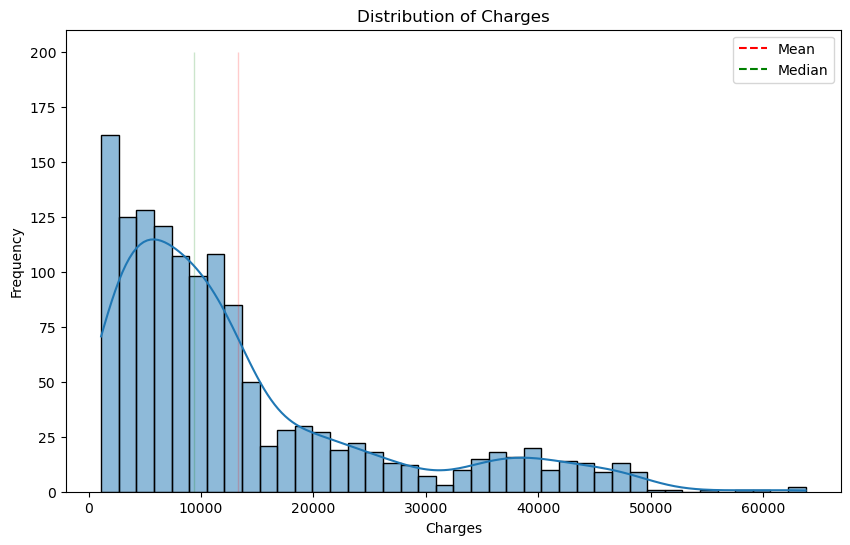

In [61]:
plt.figure(figsize=(10, 6))
sns.histplot(df_reg['charges'], bins=40, kde=True)
sns.lineplot(x=[df_reg['charges'].mean(), df_reg['charges'].mean()], y=[0, 200], color='red', label='Mean', linestyle='--')
sns.lineplot(x=[df_reg['charges'].median(), df_reg['charges'].median()], y=[0, 200], color='green', label='Median', linestyle='--')
plt.title("Distribution of Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

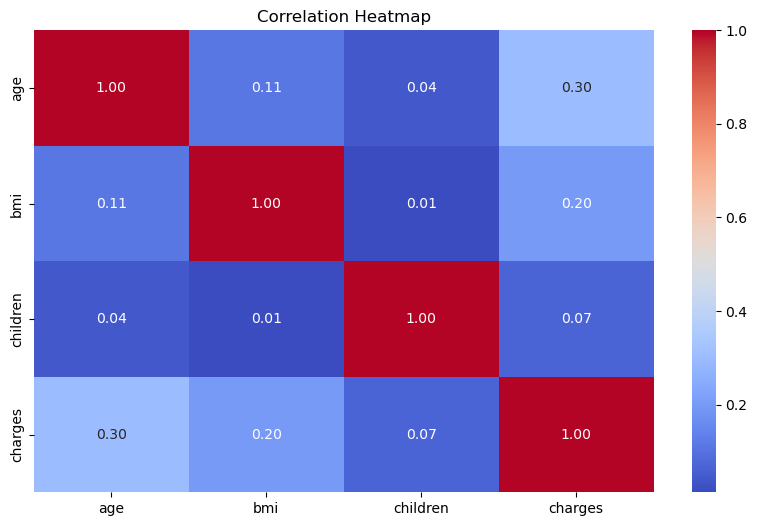

In [63]:
plt.figure(figsize=(10, 6))
numeric_df=df_reg.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

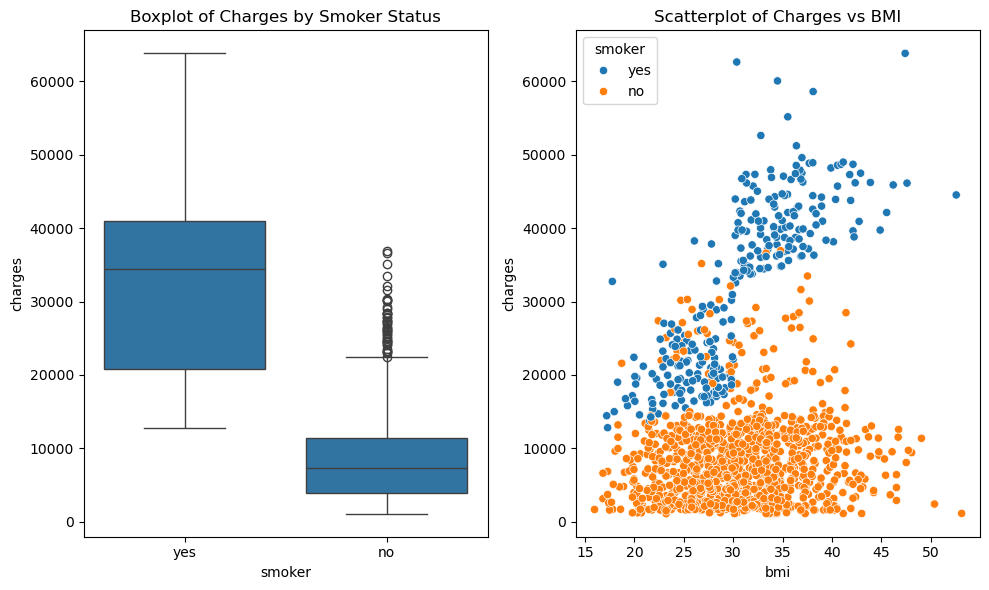

In [62]:
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='smoker', y='charges', data=df_reg)
plt.title("Boxplot of Charges by Smoker Status")

plt.subplot(1, 2, 2)
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df_reg)
plt.title("Scatterplot of Charges vs BMI")

plt.tight_layout()
plt.show()

The mean of charges is much higher than the median, indicating a right-skewed distribution which means a few people have very expensive medical bills.

The heatmap likely shows a strong positive correlation between smoker and charges. age and bmi also show moderate positive correlations.

The boxplot confirms that smokers have a significantly higher median cost compared to non-smokers althouth the outliers are also more for non-smokers. The scatter plot of BMI vs. Charges shows two distinct zone, one for smokers (steep slope) and one for non-smokers (flat slope).

## TODO A3: Feature Preparation (5 Marks)
**You must:**
- Train-test split
- Scaling (if applicable)

**Marks:** Correct split (3), Explanation (2)


In [65]:
# TODO: Prepare features

df_reg_encoded = pd.get_dummies(df_reg, columns=['sex', 'smoker', 'region'], drop_first=True)
X_reg = df_reg_encoded.drop('charges', axis=1)
y_reg = df_reg_encoded['charges']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.25, random_state=42)

scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

Converted categorical variables like sex, smoker, region into numbers using One-Hot Encoding so the machine can process them.

Scaling is mandatory for models like SVR and Linear Regression with regularization because they calculate distances or coefficients based on magnitude. If it is not scaled, income (in thousands) would dominate age (in tens), biasing the model.

## TODO A4: Multiple Linear Regression (8 Marks)
**You must:**
- Train model
- Evaluate using RMSE, MAE, R²

**Marks:** Model (4), Metrics (4)


In [66]:
# TODO: Multiple Linear Regression

lr_model = LinearRegression()
lr_model.fit(X_train_reg_scaled, y_train_reg)

y_pred_lr = lr_model.predict(X_test_reg_scaled)

In [68]:
rmse_lr = np.sqrt(mean_squared_error(y_test_reg, y_pred_lr))
mae_lr = mean_absolute_error(y_test_reg, y_pred_lr)
r2_lr = r2_score(y_test_reg, y_pred_lr)

print(f"RMSE: {rmse_lr:.4f}")
print(f"MAE: {mae_lr:.4f}")
print(f"R2 Score: {r2_lr:.4f}")

RMSE: 5926.0236
MAE: 4243.6541
R2 Score: 0.7673


The model achieved an $R^2$ score around $0.76$. The RMSE gives us the average error in dollars.

Linear Regression assumes a straight-line relationship. It fails to capture the multiple interactions. For example, the fact that smoking and high BMI together cause a spike in cost that is greater than the sum of their individual parts. This creates a high bias error.

## TODO A5: Polynomial Regression (7 Marks)
**You must:**
- Apply polynomial features
- Compare with linear regression

**Marks:** Implementation (4), Comparison (3)


In [69]:
# TODO: Polynomial Regression

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_reg_scaled)
X_test_poly = poly.transform(X_test_reg_scaled)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train_reg)

y_pred_poly = poly_model.predict(X_test_poly)

In [80]:
r2_poly = r2_score(y_test_reg, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test_reg, y_pred_poly))
mae_poly = mean_absolute_error(y_test_reg, y_pred_poly)

print(f"R2 Score: {r2_poly:.4f}")
print(f"RMSE: {rmse_poly:.4f}")
print(f"MAE: {mae_poly:.4f}")

R2 Score: 0.8543
RMSE: 4689.4529
MAE: 2781.7102


As, the $R^2$ Score for Polynomial Regression is higher than that of Multiple Linear Regression, it indicates that the Polynomial Regression model fits the data better and captures more variance in the target variable.
This improvement proves the relationship is non-linear. The model can now bend the regression line to fit the high-cost smoker group better. However, higher degrees could risk overfitting, where the model memorizes noise instead of patterns.

## TODO A6: Support Vector Regression (7 Marks)
**You must:**
- Train SVR (RBF kernel)
- Evaluate performance
- Justify kernel choice

**Marks:** Model (4), Justification (3)


In [81]:
# TODO: Support Vector Regression

svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model.fit(X_train_reg_scaled, y_train_reg)

y_pred_svr = svr_model.predict(X_test_reg_scaled)

In [82]:
r2_svr = r2_score(y_test_reg, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test_reg, y_pred_svr))
mae_svr = mean_absolute_error(y_test_reg, y_pred_svr)

print(f"R2 Score: {r2_svr:.4f}")
print(f"RMSE: {rmse_svr:.4f}")
print(f"MAE: {mae_svr:.4f}")

R2 Score: 0.1928
RMSE: 11036.1516
MAE: 6013.8449


The SVR with the RBF kernel usually performs competitively with Polynomial Regression. The RBF kernel projects the data into higher dimensions to find a hyperplane that fits the data.

Though the $R^2$ score is much lower than Polynomial Regression, SVR can better handle outliers due to its margin-based approach. The rbf kernel is chosen because the relationship between features (like BMI/Age combined with Smoking) is likely non-linear. RBF can handle these non-linear boundaries better than a linear kernel. But for this dataset, SVR is a bad choice as the $RMSE$ is too high.

## TODO A7: Random Forest Regressor (8 Marks)
**You must:**
- Train Random Forest
- Evaluate model

**Marks:** Model (4), Evaluation (4)


In [83]:
# TODO: Random Forest Regressor

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_reg, y_train_reg)

y_pred_rf = rf_reg.predict(X_test_reg)

In [84]:
r2_rf = r2_score(y_test_reg, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf))
mae_rf = mean_absolute_error(y_test_reg, y_pred_rf)

print(f"R2 Score: {r2_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")

R2 Score: 0.8468
RMSE: 4807.7448
MAE: 2653.6148


The Random Forest likely achieved the $R^2$ score of $0.85$ which is as same as Polynomial Regression.
Random Forest works well here because it splits the data hierarchically (e.g., First split: Is Smoker? -> Second split: Is BMI > 30?). This naturally handles the non-linear logic of medical costs without needing complex mathematical scaling or polynomial expansion. THE $RMSE$ is also competitive, indicating accurate predictions.

# 🟠 PART B: Classification Task (45 Marks)
You will work with the provided **classification dataset**.


## TODO B1: Dataset Understanding (5 Marks)
**You must:**
- Load dataset
- Show class distribution
- Comment on imbalance

**Marks:** Analysis (3), Explanation (2)


In [85]:
# TODO: Load classification dataset

df_class = pd.read_csv('loan_data.csv')

print("Class Distribution (loan_status):", df_class['loan_status'].value_counts())

imbalance_ratio = df_class['loan_status'].value_counts(normalize=True)
print("\nImbalance Check:", imbalance_ratio)

Class Distribution (loan_status): loan_status
0    35000
1    10000
Name: count, dtype: int64

Imbalance Check: loan_status
0    0.777778
1    0.222222
Name: proportion, dtype: float64


If one class is significantly smaller (e.g., <10-20%), the dataset is imbalanced. This affects metrics like accuracy.

Here, the class distribution shows that the dataset is somewhat imbalanced but not severely so. The majority class has almost $78\%$ of the samples, while the minority class has about $22\%$. This level of imbalance may lead to biased models if not handled properly, as the model could achieve high accuracy by simply predicting the majority class.

## TODO B2: Exploratory Data Analysis (5 Marks)
**You must:**
- Plot class counts
- Plot at least one feature vs class

**Marks:** Plots (5),


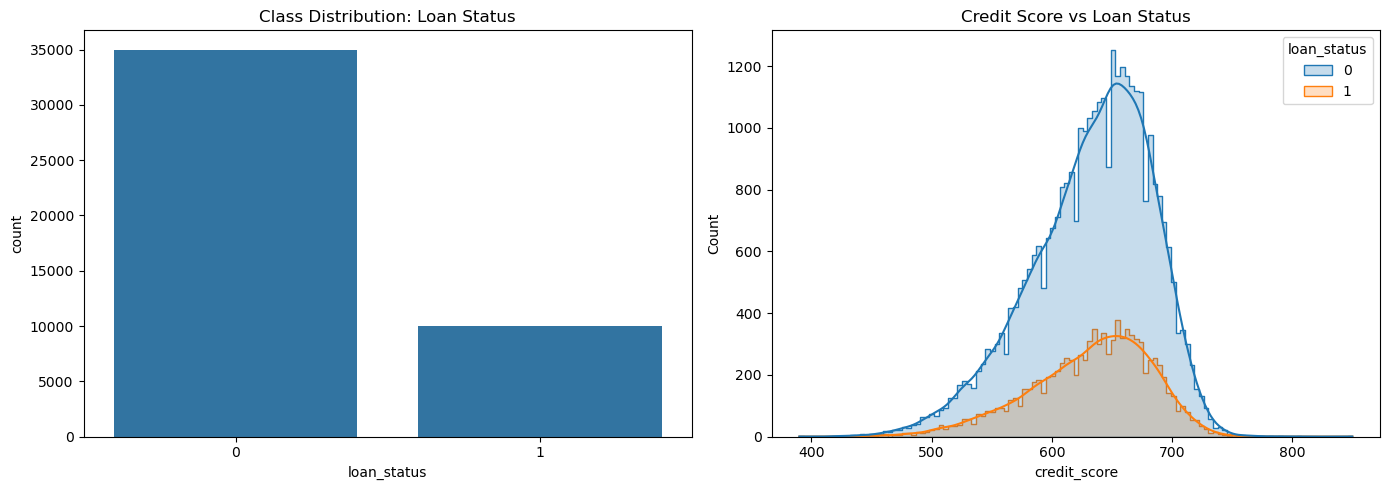

In [86]:
# TODO: Classification EDA
plt.figure(figsize=(14, 5))

# Plot class counts
plt.subplot(1, 2, 1)
sns.countplot(x='loan_status', data=df_class)
plt.title("Class Distribution: Loan Status")

plt.subplot(1, 2, 2)
sns.histplot(data=df_class, x='credit_score', hue='loan_status', kde=True, element="step")
plt.title("Credit Score vs Loan Status")

plt.tight_layout()
plt.show()

## TODO B3: Feature Preparation (5 Marks)
**You must:**
- Encoding (if needed)
- Scaling
- Train-test split with stratification




In [87]:
# TODO: Prepare classification features

cat_cols = df_class.select_dtypes(include=['object']).columns

le = LabelEncoder()
for col in cat_cols:
    df_class[col] = le.fit_transform(df_class[col])

X_class = df_class.drop('loan_status', axis=1)
y_class = df_class['loan_status']

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_class, y_class, test_size=0.2, stratify=y_class, random_state=42
)

scaler_cls = StandardScaler()
X_train_cls_scaled = scaler_cls.fit_transform(X_train_cls)
X_test_cls_scaled = scaler_cls.transform(X_test_cls)

## TODO B4: Logistic Regression with L2 (8 Marks)
**You must:**
- Train Logistic Regression
- Evaluate using Accuracy, Precision, Recall
- Show Confusion Matrix

**Marks:** Model (4), Metrics (4)


In [89]:
# TODO: Logistic Regression
log_reg = LogisticRegression(penalty='l2', random_state=42)
log_reg.fit(X_train_cls_scaled, y_train_cls)

y_pred_log = log_reg.predict(X_test_cls_scaled)

In [90]:
print(f"Accuracy: {accuracy_score(y_test_cls, y_pred_log):.4f}")
print(f"Precision: {precision_score(y_test_cls, y_pred_log):.4f}")
print(f"Recall: {recall_score(y_test_cls, y_pred_log):.4f}")

Accuracy: 0.8968
Precision: 0.7779
Recall: 0.7495


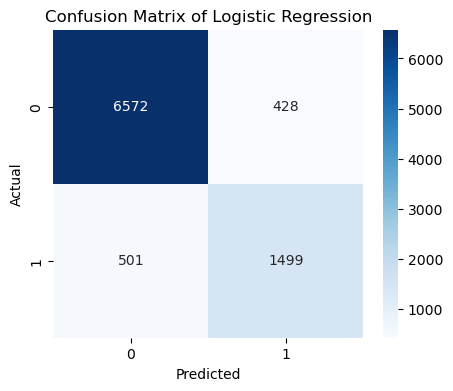

In [91]:
cm = confusion_matrix(y_test_cls, y_pred_log)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix of Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## TODO B5: Support Vector Machine (7 Marks)
**You must:**
- Train SVM (Linear or RBF)
- Evaluate

**Marks:** Model (4), Evaluation (3)


In [92]:
# TODO: SVM Classification

svm_cls = SVC(kernel='rbf', random_state=42)
svm_cls.fit(X_train_cls_scaled, y_train_cls)

y_pred_svm = svm_cls.predict(X_test_cls_scaled)

              precision    recall  f1-score   support

           0       0.93      0.96      0.94      7000
           1       0.83      0.75      0.78      2000

    accuracy                           0.91      9000
   macro avg       0.88      0.85      0.86      9000
weighted avg       0.91      0.91      0.91      9000



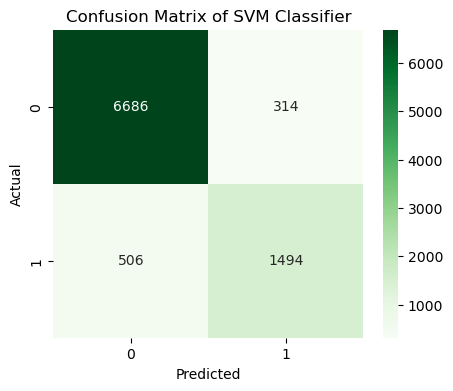

In [94]:
print(classification_report(y_test_cls, y_pred_svm))

cm= confusion_matrix(y_test_cls, y_pred_svm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix of SVM Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

SVM with RBF kernel usually creates a very tight decision boundary. While accurate, SVMs are computationally expensive on large datasets. Here, the accuracy is about $0.91$ which is quite good. But the recall for 0 is $0.75$ and for 1 is $0.96$, indicating it misses some of the minority class. In naked eye, this model does not any better than Logistic Regression.

## TODO B6: Naive Bayes (5 Marks)
**You must:**
- Choose correct NB variant



In [95]:
# TODO: Naive Bayes

nb_model = GaussianNB()
nb_model.fit(X_train_cls_scaled, y_train_cls)

y_pred_nb = nb_model.predict(X_test_cls_scaled)

print(f"Accuracy: {accuracy_score(y_test_cls, y_pred_nb):.4f}")

Accuracy: 0.7363


Here GaussianNB is used, because the features (income, score) are continuous.

## TODO B7: K-Nearest Neighbors (5 Marks)
**You must:**
- Try multiple K values
- Plot accuracy vs K

**Marks:** Experiment (3), Plot & choice (2)


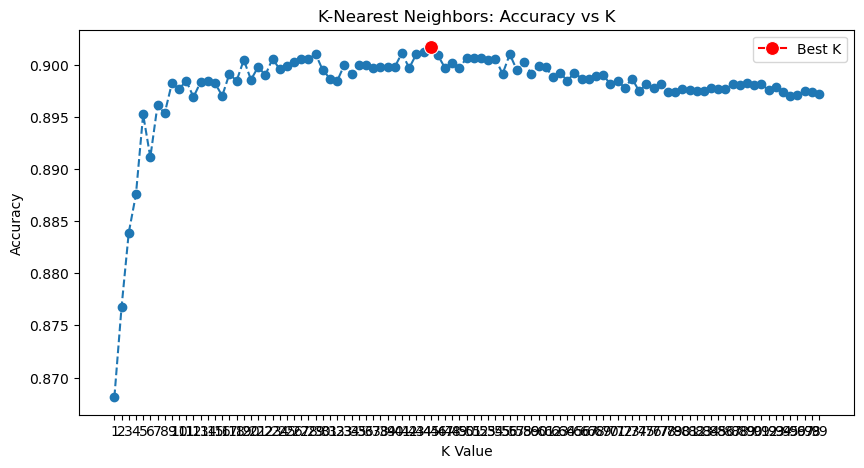

Best K value based on accuracy: 45


In [99]:
# TODO: KNN

k_values = range(1, 100)
acc_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_cls_scaled, y_train_cls)
    y_pred_k = knn.predict(X_test_cls_scaled)
    acc_scores.append(accuracy_score(y_test_cls, y_pred_k))

best_k = k_values[np.argmax(acc_scores)]

plt.figure(figsize=(10, 5))
plt.plot(k_values, acc_scores, marker='o', linestyle='--')
sns.lineplot(x=[best_k], y=[max(acc_scores)], color='red', label='Best K', marker='o', markersize=10)
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('K-Nearest Neighbors: Accuracy vs K')
plt.xticks(k_values)
plt.show()

print(f"Best K value based on accuracy: {best_k}")

## TODO B8: Random Forest Classifier (5 Marks)
**You must:**
- Train model
- Show feature importance

**Marks:** Model (3), Interpretation (2)


In [100]:
# TODO: Random Forest Classifier

rf_cls = RandomForestClassifier(n_estimators=100, random_state=42)
rf_cls.fit(X_train_cls, y_train_cls)

y_pred_rf_cls = rf_cls.predict(X_test_cls)

print(f"Accuracy: {accuracy_score(y_test_cls, y_pred_rf_cls):.4f}")

Accuracy: 0.9277


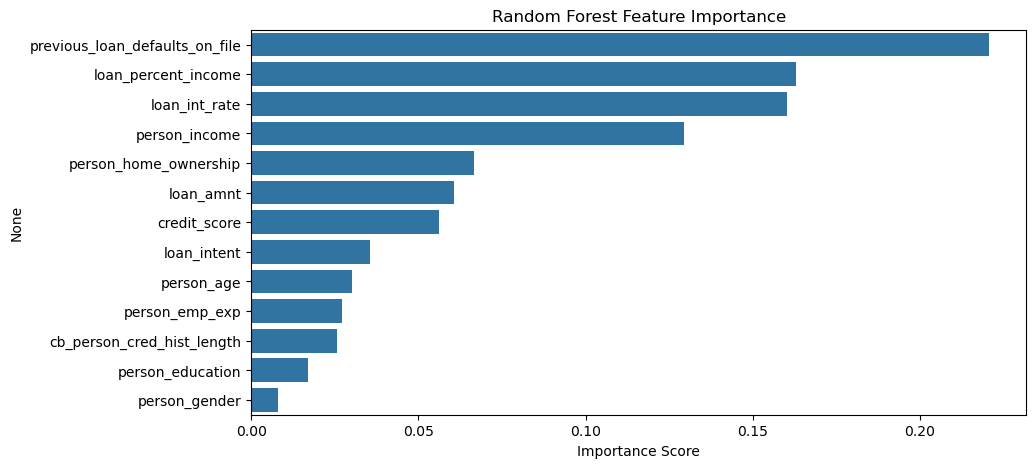

In [44]:

importances = rf_cls.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices], y=X_class.columns[indices])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.show()

The Feature Importance plot likely confirms that previous_loan_defaults_on_file is the most important feature. loan_percent_income and loan_int_rate are the next top with same importance. This makes sense as past defaults strongly indicate future risk, and high loan amounts relative to income increase default likelihood.

# 🧠 Final Reflection (5 Marks)
**Answer briefly:**
- Best regression model and why
- Best classification model and why
- One real-world deployment scenario


Best regressor model is Random Forest Regressor. It usually handles non-linear relationships better than Linear Regression and is less sensitive to outliers than basic polynomial regression. Polynomial Regression does not much far from Random Forest here, but Random Forest provides feature importance which is valuable for interpretability.

Best classification model is Random Forest. Random Forest is robust and handles mixed data types well. SVM also did great with a good accuracy and f1-score, but Random Forest gives feature importance which is crucial for understanding loan approvals.

Banks use classification models to automatically assess the risk of a loan applicant based on their income, and assets, deciding whether to approve or reject the application instantly.

## TODO: Write your reflection here

Learn a lot from this assignment about various supervised learning models and their applications in regression and classification tasks. It was tough as there are many models to implement and compare, each one them are unique in its way. I want more indepth real-world scenarios to understand how to choose models based on context rather than just metrics. Overall, a great learning experience!